1️⃣ Title Cell 

# GAN-Based Intrusion Detection System

# Objective
To generate synthetic attack data using GANs and improve detection of rare cyber attacks.

# Dataset
NSL-KDD Dataset

2️⃣ Import Libraries


In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

📊 3️⃣ Load Dataset


In [2]:
df = pd.read_csv(r"C:\Users\Asus\Documents\prj\GAN_Intrusion_Detection\data\nsl-kdd\KDDTrain+.txt", header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


🧾 4️⃣ Add Column Names

In [3]:
columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins",
    "logged_in","num_compromised","root_shell","su_attempted",
    "num_root","num_file_creations","num_shells","num_access_files",
    "num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate",
    "dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate",
    "dst_host_srv_rerror_rate","label","difficulty"
]

df.columns = columns

🔄 5️⃣ Convert Labels


In [4]:
df['label'] = df['label'].apply(lambda x: 0 if x == 'normal' else 1)

🔧 6️⃣ Encode + Scale

In [5]:

df = pd.get_dummies(df)

X = df.drop("label", axis=1)
y = df["label"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

✂️ 7️⃣ Train-Test Split

In [6]:

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

🤖 8️⃣ Baseline Model


In [7]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Before GAN:\n")
print(classification_report(y_test, y_pred))


Before GAN:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13469
           1       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



🧠 9️⃣ GAN MODEL (Generator + Discriminator)

In [8]:
import torch
import torch.nn as nn

# Generator
class Generator(nn.Module):
    def __init__(self, noise_dim, output_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(noise_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )

    def forward(self, z):
        return self.model(z)

# Discriminator
class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

⚡ 10️⃣ TRAIN GAN

In [9]:
# Prepare attack data (label = 1)
attack_data = X_train[y_train == 1]
attack_data = torch.tensor(attack_data, dtype=torch.float32)

noise_dim = 32
data_dim = attack_data.shape[1]

G = Generator(noise_dim, data_dim)
D = Discriminator(data_dim)

criterion = nn.BCELoss()
g_optimizer = torch.optim.Adam(G.parameters(), lr=0.0002)
d_optimizer = torch.optim.Adam(D.parameters(), lr=0.0002)

epochs = 50
batch_size = 64

for epoch in range(epochs):
    for i in range(0, len(attack_data), batch_size):
        real = attack_data[i:i+batch_size]
        batch_len = real.size(0)

        real_labels = torch.ones(batch_len, 1)
        fake_labels = torch.zeros(batch_len, 1)

        # Train Discriminator
        z = torch.randn(batch_len, noise_dim)
        fake = G(z)

        d_real = D(real)
        d_fake = D(fake.detach())

        d_loss = criterion(d_real, real_labels) + criterion(d_fake, fake_labels)

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # Train Generator
        z = torch.randn(batch_len, noise_dim)
        fake = G(z)

        g_loss = criterion(D(fake), real_labels)

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

    print(f"Epoch {epoch} | D Loss: {d_loss.item()} | G Loss: {g_loss.item()}")

Epoch 0 | D Loss: 0.22687169909477234 | G Loss: 2.161163091659546
Epoch 1 | D Loss: 0.14963850378990173 | G Loss: 3.1161880493164062
Epoch 2 | D Loss: 0.35697728395462036 | G Loss: 2.4684760570526123
Epoch 3 | D Loss: 0.18591654300689697 | G Loss: 2.7136147022247314
Epoch 4 | D Loss: 0.2263878434896469 | G Loss: 2.577049493789673
Epoch 5 | D Loss: 0.1960725486278534 | G Loss: 3.1927685737609863
Epoch 6 | D Loss: 0.15973103046417236 | G Loss: 3.883023738861084
Epoch 7 | D Loss: 0.21794001758098602 | G Loss: 3.0355517864227295
Epoch 8 | D Loss: 0.16107237339019775 | G Loss: 3.730517864227295
Epoch 9 | D Loss: 0.11912886798381805 | G Loss: 4.000143527984619
Epoch 10 | D Loss: 0.1818477213382721 | G Loss: 4.696399688720703
Epoch 11 | D Loss: 0.37184756994247437 | G Loss: 3.684871196746826
Epoch 12 | D Loss: 0.30331677198410034 | G Loss: 3.282090663909912
Epoch 13 | D Loss: 0.2986730933189392 | G Loss: 3.638258218765259
Epoch 14 | D Loss: 0.25817322731018066 | G Loss: 4.232490539550781
Epoc

11️⃣ GENERATE SYNTHETIC DATA


In [10]:
num_samples = 5000

z = torch.randn(num_samples, noise_dim)
synthetic_data = G(z).detach().numpy()
synthetic_labels = np.ones(num_samples)

🔗 12️⃣ COMBINE DATA


In [11]:
X_aug = np.vstack((X_train, synthetic_data))
y_aug = np.hstack((y_train, synthetic_labels))

📈 13️⃣ TRAIN MODEL AFTER GAN


In [12]:
model2 = RandomForestClassifier()
model2.fit(X_aug, y_aug)

y_pred2 = model2.predict(X_test)

print("After GAN:\n")
print(classification_report(y_test, y_pred2))

After GAN:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13469
           1       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



📊 1️⃣ COMPARE PERFORMANCE (Before vs After GAN)

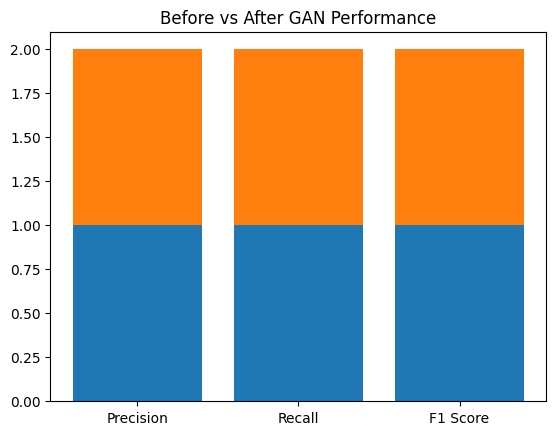

In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Before GAN
precision_before = precision_score(y_test, y_pred)
recall_before = recall_score(y_test, y_pred)
f1_before = f1_score(y_test, y_pred)

# After GAN
precision_after = precision_score(y_test, y_pred2)
recall_after = recall_score(y_test, y_pred2)
f1_after = f1_score(y_test, y_pred2)

import matplotlib.pyplot as plt

metrics = ['Precision', 'Recall', 'F1 Score']
before = [precision_before, recall_before, f1_before]
after = [precision_after, recall_after, f1_after]

x = range(len(metrics))

plt.figure()
plt.bar(x, before)
plt.bar(x, after, bottom=before)

plt.xticks(x, metrics)
plt.title("Before vs After GAN Performance")
plt.savefig("../results/performance.png")
plt.show()

📉 2️⃣ ADD SMOTE COMPARISON (VERY IMPORTANT FOR RESEARCH)

👉 This gives you novelty point



In [16]:
from imblearn.over_sampling import SMOTE

sm = SMOTE()
X_smote, y_smote = sm.fit_resample(X_train, y_train)

model3 = RandomForestClassifier()
model3.fit(X_smote, y_smote)

y_pred3 = model3.predict(X_test)

print("SMOTE:\n")
print(classification_report(y_test, y_pred3))

SMOTE:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13469
           1       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



📊 3️⃣ VISUALIZE DATA (t-SNE) 🔥

👉 Shows real vs synthetic data



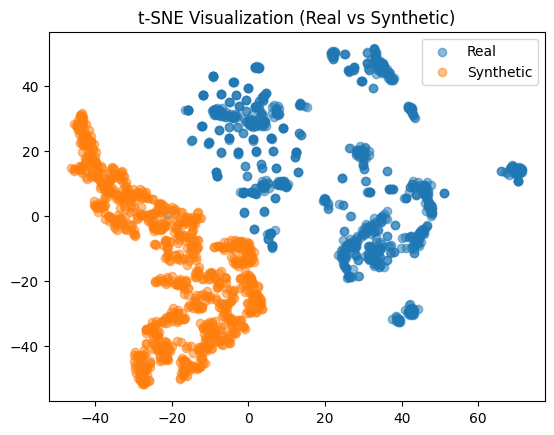

In [17]:
from sklearn.manifold import TSNE

# Take small sample
real_sample = X_train[:1000]
fake_sample = synthetic_data[:1000]

combined = np.vstack((real_sample, fake_sample))

tsne = TSNE(n_components=2, random_state=42)
reduced = tsne.fit_transform(combined)

plt.figure()

plt.scatter(reduced[:1000, 0], reduced[:1000, 1], label="Real", alpha=0.5)
plt.scatter(reduced[1000:, 0], reduced[1000:, 1], label="Synthetic", alpha=0.5)

plt.legend()
plt.title("t-SNE Visualization (Real vs Synthetic)")
plt.savefig("../results/tsne.png")
plt.show()

🚀 STEP: FINAL COMPARISON (GAN vs SMOTE vs BASELINE)

Run this to compare all models clearly 👇

In [18]:

from sklearn.metrics import precision_score, recall_score, f1_score

# Baseline
p1 = precision_score(y_test, y_pred)
r1 = recall_score(y_test, y_pred)
f1_1 = f1_score(y_test, y_pred)

# GAN
p2 = precision_score(y_test, y_pred2)
r2 = recall_score(y_test, y_pred2)
f1_2 = f1_score(y_test, y_pred2)

# SMOTE
p3 = precision_score(y_test, y_pred3)
r3 = recall_score(y_test, y_pred3)
f1_3 = f1_score(y_test, y_pred3)

print("Baseline:", p1, r1, f1_1)
print("GAN:", p2, r2, f1_2)
print("SMOTE:", p3, r3, f1_3)

Baseline: 0.9997440928090079 0.9994883165614873 0.9996161883235959
GAN: 0.9996587321900862 0.999232474842231 0.9994455580671301
SMOTE: 0.9998293224099676 0.9991471942691454 0.9994881419552978


📊 STEP: CLEAN GRAPH

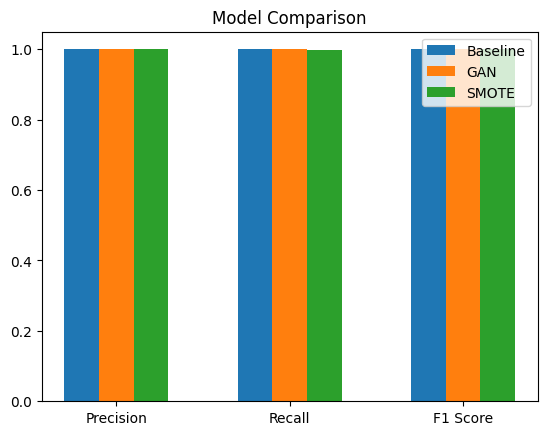

In [19]:

import matplotlib.pyplot as plt
import numpy as np

labels = ['Precision', 'Recall', 'F1 Score']

baseline = [p1, r1, f1_1]
gan = [p2, r2, f1_2]
smote = [p3, r3, f1_3]

x = np.arange(len(labels))

plt.figure()

plt.bar(x - 0.2, baseline, width=0.2, label='Baseline')
plt.bar(x, gan, width=0.2, label='GAN')
plt.bar(x + 0.2, smote, width=0.2, label='SMOTE')

plt.xticks(x, labels)
plt.legend()
plt.title("Model Comparison")

plt.savefig(r"C:\Users\Asus\Documents\prj\GAN_Intrusion_Detection\results\comparison.png")
plt.show()